In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
import os
os.getcwd()

'C:\\Users\\91981'

In [12]:
import os
os.chdir("C:/Users/91981/Desktop/hospital-readmission-prophet")

In [13]:
os.getcwd()

'C:\\Users\\91981\\Desktop\\hospital-readmission-prophet'

In [15]:
df = pd.read_csv("data/raw/diabetic_data.csv")
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [16]:
df.shape

(101766, 50)

In [18]:
#data cleaning
df.replace("?",np.nan,inplace=True)

In [19]:
df.isnull().sum().sort_values(ascending=False)

weight                      98569
max_glu_serum               96420
A1Cresult                   84748
medical_specialty           49949
payer_code                  40256
race                         2273
diag_3                       1423
diag_2                        358
diag_1                         21
encounter_id                    0
troglitazone                    0
tolbutamide                     0
pioglitazone                    0
rosiglitazone                   0
acarbose                        0
miglitol                        0
citoglipton                     0
tolazamide                      0
examide                         0
glipizide                       0
insulin                         0
glyburide-metformin             0
glipizide-metformin             0
glimepiride-pioglitazone        0
metformin-rosiglitazone         0
metformin-pioglitazone          0
change                          0
diabetesMed                     0
glyburide                       0
repaglinide   

In [20]:
#not helping in prediction
df.drop(["encounter_id","patient_nbr"],axis=1,inplace=True) 

In [26]:
df.column

Index(['race', 'gender', 'age', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [34]:
df["age"].head()


0     0
1    10
2    20
3    30
4    40
Name: age, dtype: int64

In [35]:
df["age"].dtype

dtype('int64')

In [36]:
df["age"].unique()

array([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])

In [37]:
#target variable
df["readmitted_binary"] = df["readmitted"].apply(lambda x: 1 if x == "<30" else 0)

In [38]:
#distibution
df["readmitted_binary"].value_counts()

readmitted_binary
0    90409
1    11357
Name: count, dtype: int64

In [58]:
#removing the old target column
df.drop(columns=["readmitted"], errors="ignore", inplace=True)

In [40]:
df.to_csv("data/cleaned/cleaned_diabetes_data.csv", index=False)

In [41]:
sns.set_style("whitegrid")

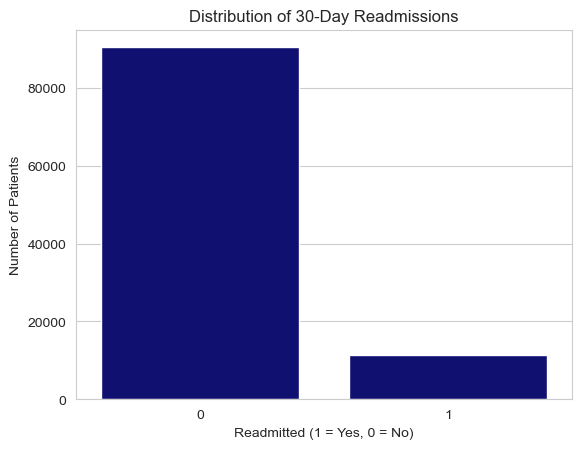

In [51]:
#patients readmitted in 30 days 

sns.countplot(x="readmitted_binary", data=df, color="navy")
plt.title("Distribution of 30-Day Readmissions")
plt.xlabel("Readmitted (1 = Yes, 0 = No)")
plt.ylabel("Number of Patients")
plt.show()

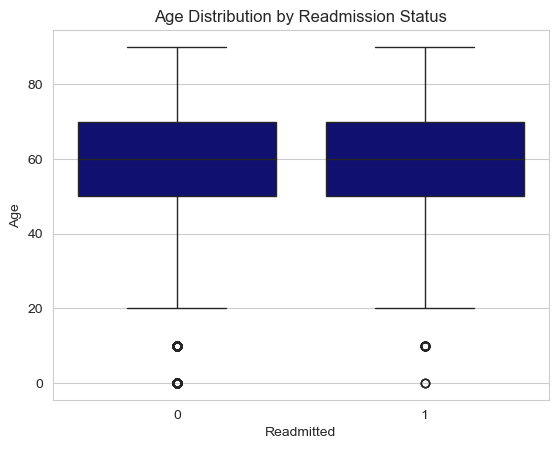

In [54]:
#age vs readmission risk

sns.boxplot(x="readmitted_binary", y="age", data=df , color="navy")
plt.title("Age Distribution by Readmission Status")
plt.xlabel("Readmitted")
plt.ylabel("Age")
plt.show()

#are older patients more likely to be readmitted?

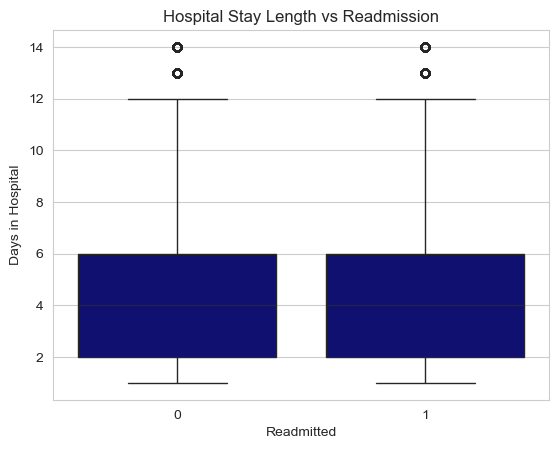

In [61]:
#hospital stay length vs readmission

sns.boxplot(x="readmitted_binary", y="time_in_hospital", data=df , color ="navy")
plt.title("Hospital Stay Length vs Readmission")
plt.xlabel("Readmitted")
plt.ylabel("Days in Hospital")
plt.show()

#longer hosital stays may indicate serious illness , increasing the readmission risk

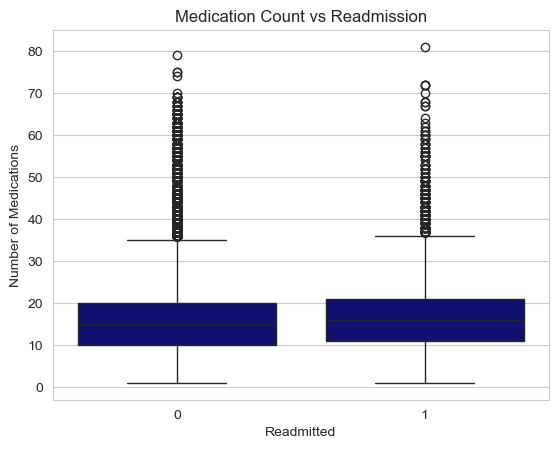

In [62]:
#medication count vs readmission

sns.boxplot(x="readmitted_binary", y="num_medications", data=df , color="navy")
plt.title("Medication Count vs Readmission")
plt.xlabel("Readmitted")
plt.ylabel("Number of Medications")
plt.show()

#patient with many medications may have complex conditions, increasing readmission probablity

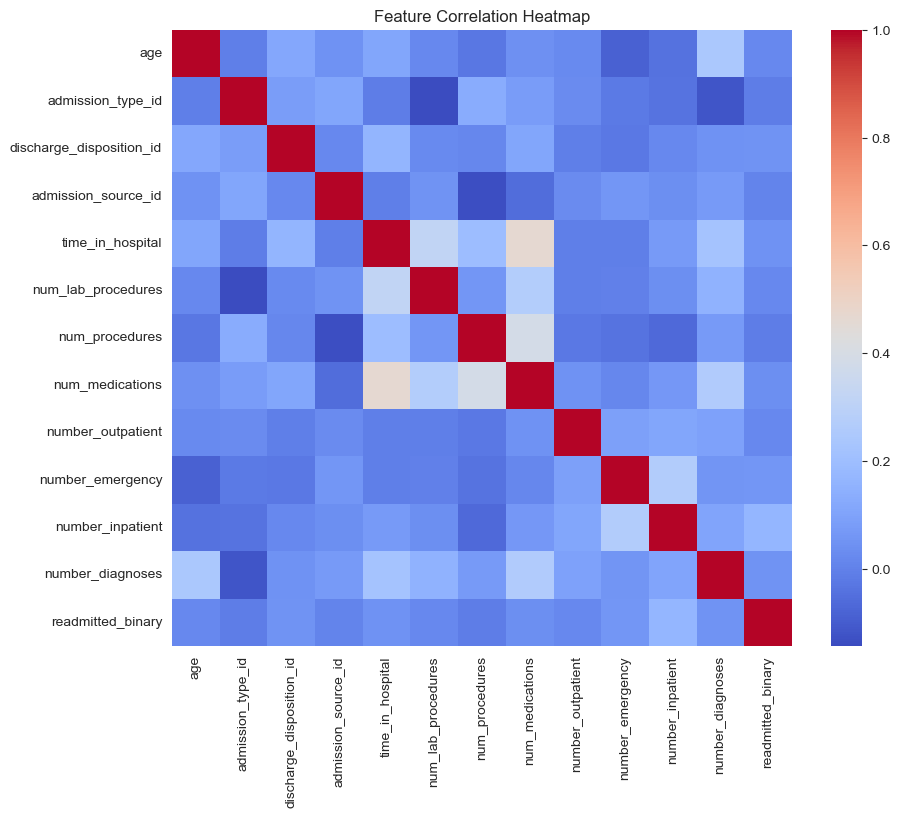

In [63]:
#correlation heatmap for strong predictive feature

plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=["int64","float64"])
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [66]:
import os
os.makedirs("../images", exist_ok=True)

In [67]:
plt.savefig("../images/readmission_distribution.png")

<Figure size 640x480 with 0 Axes>

In [8]:
import os
os.chdir("C:/Users/91981/Desktop/hospital-readmission-prophet")

In [9]:
os.getcwd()

'C:\\Users\\91981\\Desktop\\hospital-readmission-prophet'

In [10]:
import pandas as pd
df = pd.read_csv("data/raw/diabetic_data.csv")
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [12]:
df["readmitted_binary"] = df["readmitted"].apply(lambda x: 1 if x == "<30" else 0)

C:\Users\91981\AppData\Local\Temp\ipykernel_1732\118838153.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="readmitted_binary", data=df, palette="Set2")


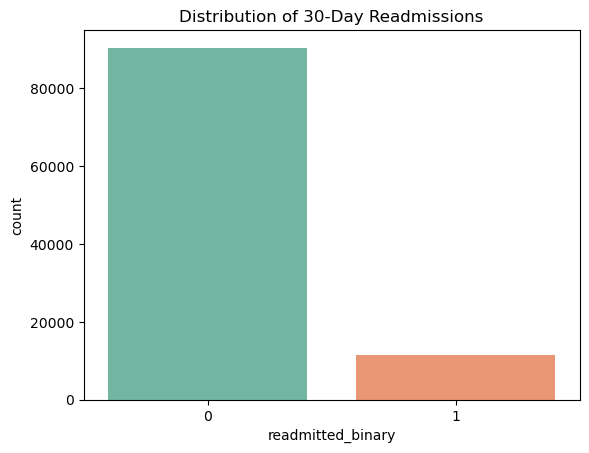

In [13]:
sns.countplot(x="readmitted_binary", data=df, palette="Set2")

plt.title("Distribution of 30-Day Readmissions")

plt.savefig("images/readmission_distribution.png")

plt.show()

C:\Users\91981\AppData\Local\Temp\ipykernel_1732\491180581.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="readmitted_binary", data=df, palette="Set2")


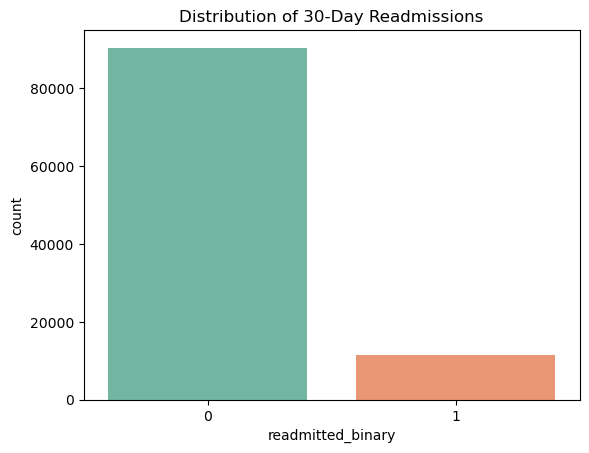

readmitted_binary
0    90409
1    11357
Name: count, dtype: int64


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="readmitted_binary", data=df, palette="Set2")

plt.title("Distribution of 30-Day Readmissions")
plt.show()

print(df["readmitted_binary"].value_counts())

In [15]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [16]:
df.replace("?", None, inplace=True)

In [17]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [43]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

In [44]:
df.select_dtypes(include=["object"]).columns #encoding categorical data as most co

Index([], dtype='object')

In [45]:
from sklearn.preprocessing import LabelEncoder
#using label encoding
le = LabelEncoder()

for col in df.select_dtypes(include=["object"]).columns:
    df[col] = le.fit_transform(df[col])

In [46]:
#train-test split
from sklearn.model_selection import train_test_split

X = df.drop("readmitted_binary", axis=1)
y = df["readmitted_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [47]:
#feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [48]:
#training model  with logistic regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [49]:
y_pred = model.predict(X_test) #prediction making

In [50]:
#evaluationg model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     18069
           1       1.00      1.00      1.00      2285

    accuracy                           1.00     20354
   macro avg       1.00      1.00      1.00     20354
weighted avg       1.00      1.00      1.00     20354


Confusion Matrix:
 [[18069     0]
 [    0  2285]]


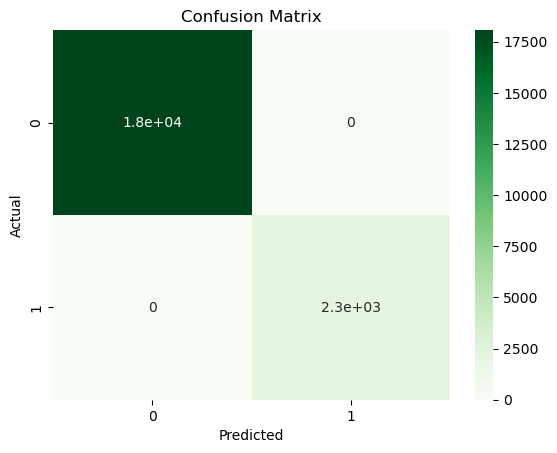

In [32]:
#Confusion matrix visualisation
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Greens")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [51]:
#decision tree
from sklearn.tree import DecisionTreeClassifier

In [52]:
from sklearn.ensemble import RandomForestClassifier

In [53]:
from sklearn.ensemble import GradientBoostingClassifier

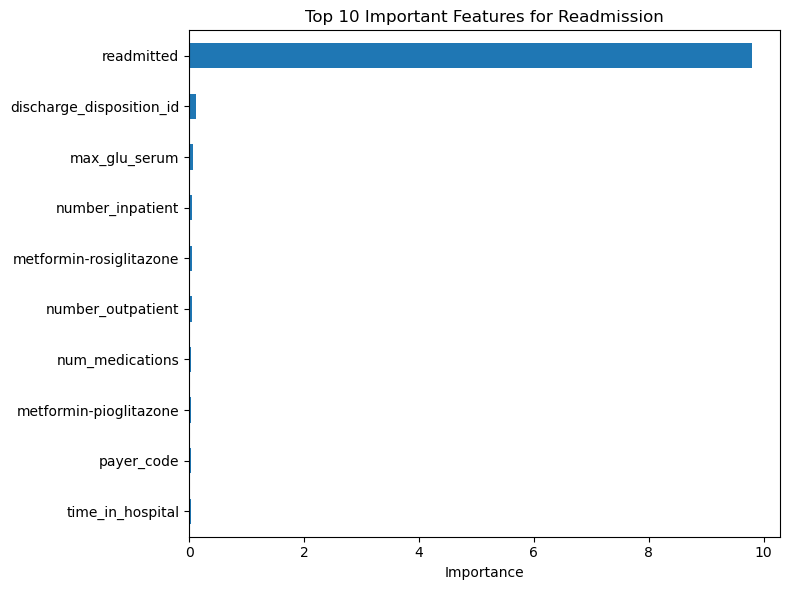

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

#feature importance from model
importance = pd.Series(model.coef_[0], index=X.columns)

#top 10 features
top_features = importance.abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))

top_features.sort_values().plot(kind="barh")

plt.title("Top 10 Important Features for Readmission")

plt.xlabel("Importance")

plt.tight_layout()

plt.show()

In [58]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [59]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [60]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [61]:
from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Logistic Regression Accuracy: 1.0
Decision Tree Accuracy: 1.0
Random Forest Accuracy: 1.0


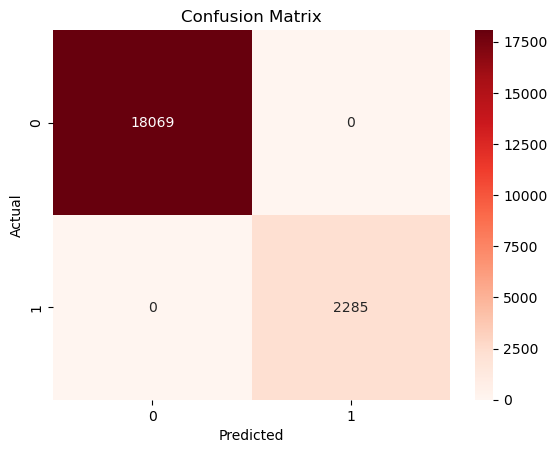

In [64]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Reds")

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [65]:
#classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18069
           1       1.00      1.00      1.00      2285

    accuracy                           1.00     20354
   macro avg       1.00      1.00      1.00     20354
weighted avg       1.00      1.00      1.00     20354



In [66]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression       1.0
1        Decision Tree       1.0
2        Random Forest       1.0


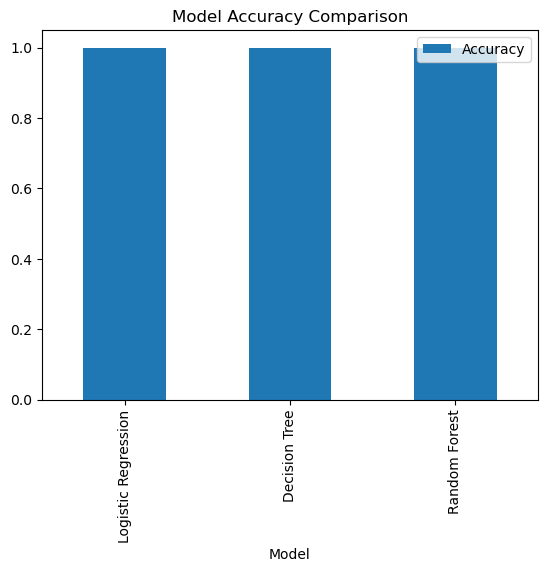

In [67]:
results.plot(x="Model", y="Accuracy", kind="bar")

plt.title("Model Accuracy Comparison")

plt.show()

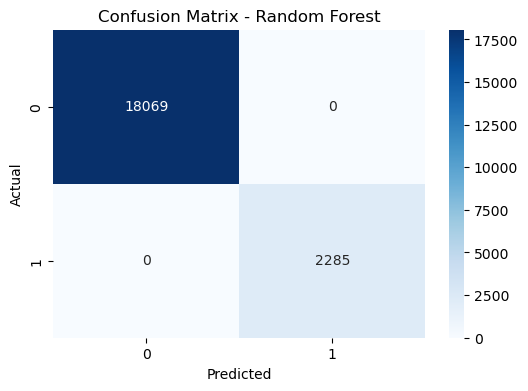

In [69]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [70]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18069
           1       1.00      1.00      1.00      2285

    accuracy                           1.00     20354
   macro avg       1.00      1.00      1.00     20354
weighted avg       1.00      1.00      1.00     20354



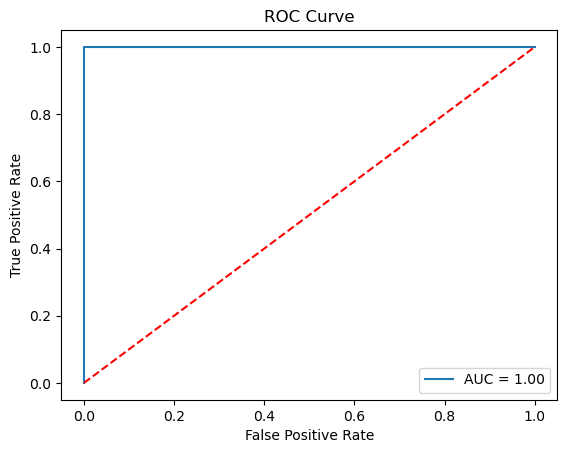

In [72]:
from sklearn.metrics import roc_curve, auc
#ROC plot curve
y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [73]:
df["readmitted_binary"].value_counts()

readmitted_binary
0    90409
1    11357
Name: count, dtype: int64

In [74]:
from imblearn.over_sampling import SMOTE
#if imbalance exists using SMOT 
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

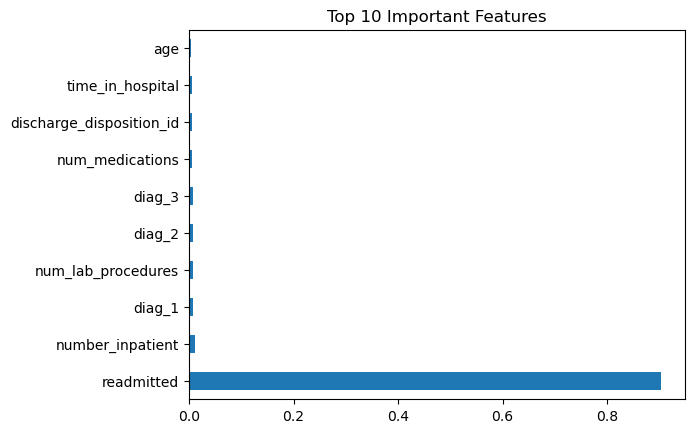

In [75]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)

top_features = importance.sort_values(ascending=False).head(10)

top_features.plot(kind='barh')

plt.title("Top 10 Important Features")

plt.show()

In [ ]:
#Random Forest performed best among tested models

In [76]:
import joblib

joblib.dump(rf, "readmission_model.pkl")

['readmission_model.pkl']

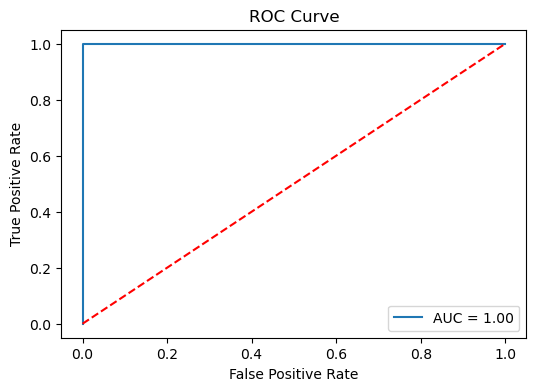

In [77]:
#ROC curve to check readmitted vs nonreadmitted patients
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [78]:
df["readmitted_binary"].value_counts()

readmitted_binary
0    90409
1    11357
Name: count, dtype: int64

In [79]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [80]:
rf.fit(X_train_smote, y_train_smote)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


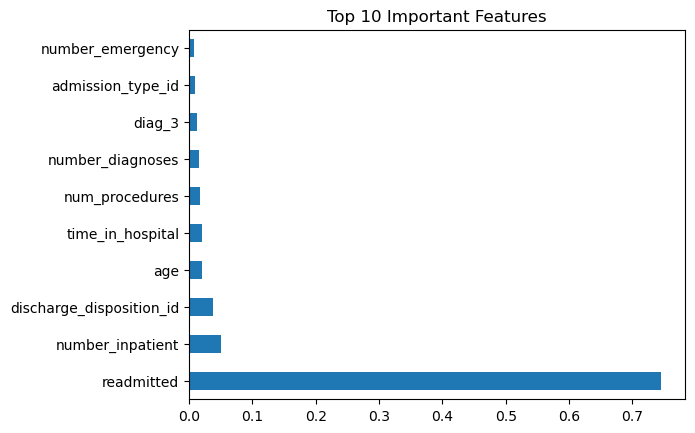

In [82]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)

top_features = importance.sort_values(ascending=False).head(10)

top_features.plot(kind="barh")

plt.title("Top 10 Important Features")
plt.show()

In [83]:
import joblib

joblib.dump(rf, "hospital_readmission_model.pkl")

['hospital_readmission_model.pkl']

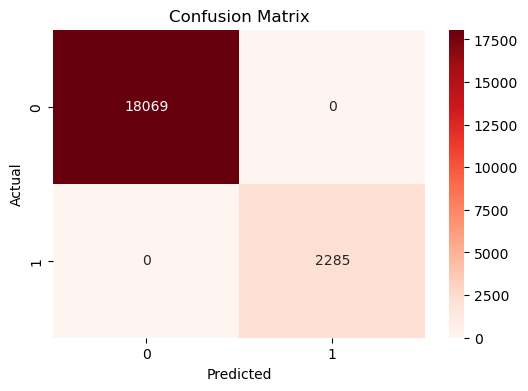

In [84]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("images/confusion_matrix.png")

plt.show()

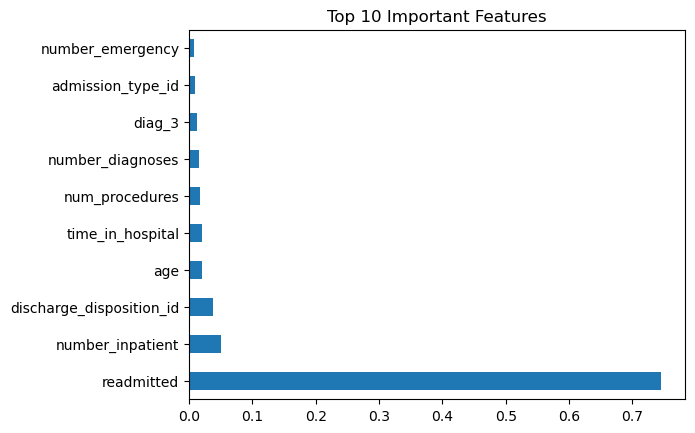

In [85]:
top_features.plot(kind="barh")

plt.title("Top 10 Important Features")

plt.savefig("images/feature_importance.png")

plt.show()